In [3]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path(os.path.abspath('')).resolve().parents[2]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


import nvitk as nv
from nvitk import db

repo, xnat_config = db.get_repo_from_settings(return_xnat_config=True)

12:31:13 | INFO     | Using local root: ~/nvitk/dataset/nvitk-dataset


DB Setup

In [4]:
aux = repo.image(modality='4dflow', variables=['flow_mean'], wide=False)
aux = aux[(aux['variable_id' ] == 'flow_mean') & (aux['value_num'].notna())]

_STATSMODELS_BASE_DIR = Path('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/DB/nvitk-statmodels/')

_SUBJECTS = pd.unique(aux.subject_uid)
_CLINICAL_VARS = ['age_at_mri', 'apoe_group', 'apoe', 'bmi', 'pp', 'map', 'hematocrit', 'pedframi10', 'pedframi30', 'sex', 'score2', 'tacsctot_group']
_PLAQUE_VARS = ['total_carotid_plaque_vol', 'total_femoral_plaque_vol', 'total_plaque_vol', 'right_carotid_plaque_vol', 'left_carotid_plaque_vol']
_COGNITIVE_VARS = ['z_compo_processingspeed', 'z_compo_globalfull', 'z_compo_epismemory', 'z_compo_attworkmemospeed']
_FLOW_VARS = ['flow_mean', 'pi']
_ASL_VARS = ['mean_cbf', 'att_mean']

TERRITORY_FLOW_REGIONS: dict[str, tuple[str, ...]] = {
    "ACA": ( "left_aca", "right_aca"),
    "MCA": ("left_mca", "right_mca"),
    "PCA": ("left_pca", "right_pca"),
    "Basilar": ("basilar",),
    "WB": ("left_ica", "right_ica", "basilar"),
    # "ICA-WS": ("left_ica", "right_ica"),
    # "ICA-WB": ("left_ica", "right_ica"),
    # "Venous-WB": ("sagital_sinus", "straight_sinus", "left_transverse", "right_transverse"),
}

TERRITORY_ASL_V8_REGIONS: dict[str, tuple[str, ...]] = {
    "ACA": ("left_aca_8", "right_aca_8",),
    "MCA": ("left_mca_8", "right_mca_8",),
    "PCA": ("left_pca_8", "right_pca_8",),
    "Basilar": ("left_basilar_8", "right_basilar_8",),
    "WB": ("ctx-whole-brain",)
    # "ICA-WS": ("watershed_0", "watershed_8"),
    # "ICA-WB": ("ctx_whole_brain",),
    # "Venous-WB": ("ctx_whole_brain",),
}

clinical  = repo.clinical(variables=_CLINICAL_VARS, filters={'subject_uid': {'$in': _SUBJECTS}})
plaque    = repo.clinical(variables=_PLAQUE_VARS, filters={'subject_uid': {'$in': _SUBJECTS}})
cognitive = repo.cognitive(variables=_COGNITIVE_VARS, filters={'subject_uid': {'$in': _SUBJECTS}})
clinical   = repo.join([clinical, plaque, cognitive])

flow      = repo.image(modality='4dflow', variables=_FLOW_VARS, filters={'subject_uid': {'$in': _SUBJECTS}})
asl       = repo.image(modality='asl', variables=_ASL_VARS, atlas='vascular-8', filters={'subject_uid': {'$in': _SUBJECTS}})
asl_wb    = repo.image(
    modality='asl', variables=_ASL_VARS, atlas='desikan', 
    regions=['ctx-whole-brain'],
    filters={'subject_uid': {'$in': _SUBJECTS}}
    )
image_df  = repo.join([flow, asl, asl_wb])

territory_df = nv.stats.melt_imaging_territories(
    image_df, id_cols=['subject_uid'], 
    flow_vars=_FLOW_VARS, asl_vars=_ASL_VARS, 
    territory_flow_regions=TERRITORY_FLOW_REGIONS,
    territory_asl_v8_regions=TERRITORY_ASL_V8_REGIONS,
    include_frame_index=False
)

_COVAR_FOR_MODEL = [
    "tacsctot_group",
    "age_at_mri",
    "sex",
    "hematocrit",
    "score2",
    "pp",
    "map"
]
_cov = [c for c in _COVAR_FOR_MODEL if c in clinical.columns]

TERRITORY_DEFINITIONS = {
    name: {"flow": TERRITORY_FLOW_REGIONS[name], "asl": TERRITORY_ASL_V8_REGIONS[name]}
    for name in TERRITORY_FLOW_REGIONS
}
analysis_df = nv.stats.build_analysis_df_from_territory_definitions(
    image_df,
    clinical,
    TERRITORY_DEFINITIONS,
    flow_vars=_FLOW_VARS,
    asl_vars=_ASL_VARS,
    covariate_cols=_cov,
)

analysis_df = analysis_df.dropna().reset_index(drop=True)
analysis_df["age_c"] = analysis_df["age_at_mri"] - float(analysis_df["age_at_mri"].mean())
analysis_df = analysis_df.drop(columns=['age_at_mri'])
analysis_df['territory'] = pd.Categorical(analysis_df['territory'], categories=list(TERRITORY_ASL_V8_REGIONS.keys()), ordered=True)
analysis_df['tacsctot_group'] = pd.Categorical(analysis_df['tacsctot_group'], categories=['g0', 'g1', 'g2', 'g3'], ordered=True)
analysis_df['mean_cbf'] = analysis_df['mean_cbf'].astype(np.float32)
analysis_df['hematocrit'] = analysis_df['hematocrit'].astype(np.float32)
analysis_df['score2'] = analysis_df['score2'].astype(np.float32)
analysis_df['pp'] = analysis_df['pp'].astype(np.float32)
analysis_df['age_c'] = analysis_df['age_c'].astype(np.float32)
analysis_df

,subject_uid,territory,flow_mean,pi,mean_cbf,att_mean,tacsctot_group,sex,hematocrit,score2,pp,map,age_c
0,PESA1006009,ACA,111.646968,0.762656,58.483761,1.280129,g0,1,47.0,4.625464,49.0,91.333333,5.109503
1,PESA10061584,ACA,70.072381,0.920645,40.072781,1.305152,g2,1,48.0,5.979170,53.0,102.666667,6.509502
2,PESA10067929,ACA,117.784776,0.659989,59.831661,1.226889,g0,1,42.0,7.063850,62.0,106.666667,6.779502
3,PESA10086976,ACA,129.008313,0.608765,57.035610,1.221132,g0,0,45.0,1.596673,32.0,89.666667,-4.570498
4,PESA10112400,ACA,113.482773,0.971021,56.868347,1.232920,g0,1,48.0,3.986971,58.0,108.333333,-4.020497
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1362,PESA9897316,Basilar,216.781694,0.755665,45.512760,1.109104,g1,1,52.0,4.760891,39.0,81.0,-2.410497
1363,PESA9928801,Basilar,184.485604,0.589528,57.890354,1.080371,g0,0,45.0,2.783649,31.0,83.333333,4.369503
1364,PESA9935104,Basilar,250.168143,0.736223,39.562092,1.066424,g0,0,45.0,2.478144,46.0,91.333333,2.829503
1365,PESA9947716,Basilar,310.847985,0.811056,50.096241,1.116286,g1,1,42.0,3.722327,43.0,85.333333,1.369503


PP -> PI

PI -> PP

PI -> ATT

PP -> ATT

In [5]:
# model_dir = 'pp_pi'
# formula_m = (
#     f"pp ~ pi + age_c + sex + hematocrit + score2"
# )

# _model_cols = [
#     "pp",
#     "pi",
#     "territory",
#     "age_c",
#     "sex",
#     "hematocrit",
#     "subject_uid",
#     "score2"
# ]

# res_mediator, df_fit_mediator, _meta_mediator = nv.stats.fit_or_load_mixedlm(
#     model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
#     data=analysis_df,
#     formula=formula_m,
#     groups="territory",
#     re_formula="1",
#     vc_formula={"subject": "0 + C(subject_uid)"},
#     overwrite=False,
#     required_columns=_model_cols,
# )

# nv.stats.print_mixedlm_info(
#     res_mediator,
#     outcome_name="pp",
#     group_name="territory",
#     vc_group_name="subject_uid",
#     output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
# )

# fig = nv.stats.plot_mixedlm_params(
#     result=res_mediator,
#     df_fit=df_fit_mediator,
#     x="pi",
#     y="pp",
#     group="territory",
#     errorbar=True,
#     mode="auto",
#     hue="territory",
#     include_points=True,
#     output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
#     title="pp ~ pi",
#     x_label="pi",
#     y_label="pp",
#     covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_mediator["hematocrit"].mean()), "age_c": float(df_fit_mediator["age_c"].mean()), "score2": float(df_fit_mediator["score2"].mean())},
# )

# # fig.axes[0].set_ylim(30, 60)

# fig = nv.stats.plot_mixedlm_params(
#     result=res_mediator,
#     df_fit=df_fit_mediator,
#     x="pi",
#     y="pp",
#     group="territory",
#     errorbar=True,
#     mode="auto",
#     hue="territory",
#     include_points=False,
#     output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
#     title="pp ~ pi",
#     x_label="pi",
#     y_label="pp", 
#     covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_mediator["hematocrit"].mean()), "age_c": float(df_fit_mediator["age_c"].mean()), "score2": float(df_fit_mediator["score2"].mean())},
# )

12:31:16 | INFO     | ========================================================================================
Mixed Linear Model - pi
Formula: pi ~ pp + age_c + sex + hematocrit + score2
Observations: 1,367
territory groups: 4

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                               0.7366      0.0678   1.759e-27       ***
pp                                      0.0045      0.0005   6.015e-17       ***
age_c                                   0.0086      0.0012   7.353e-12       ***
sex                                    -0.0495      0.0126   9.144e-05       ***
hematocrit                             -0.0012      0.0013      0.3531        NS
score2                                 -0.0010      0.0037      0.7956        NS

territory random effects covariance
----------------------------------------------------------------

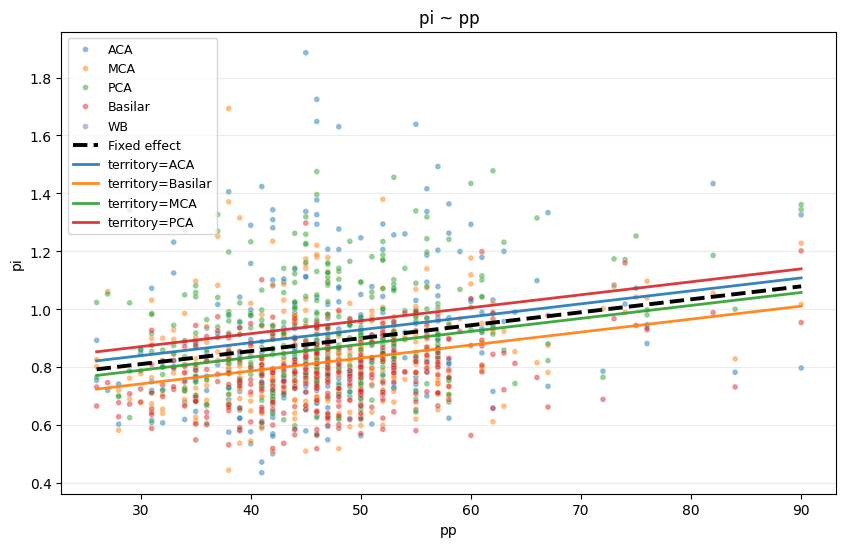

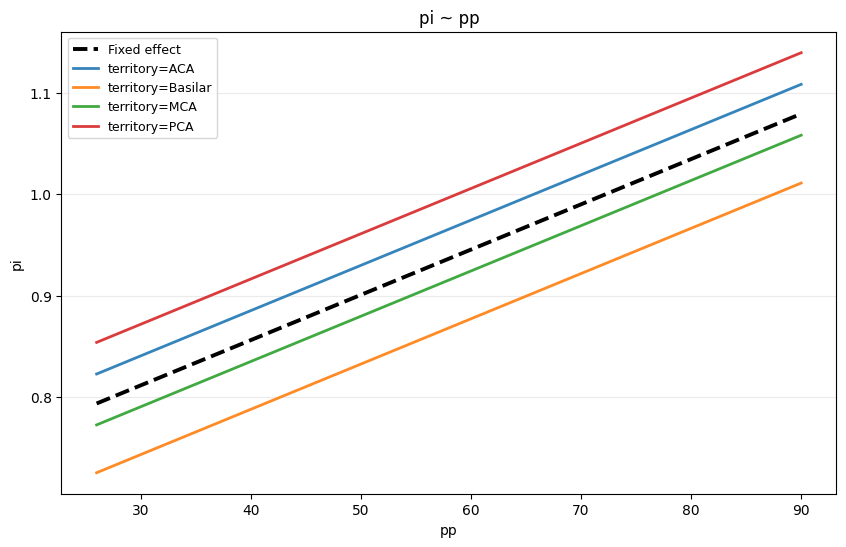

In [6]:
model_dir = 'pi_pp'
formula_m = (
    f"pi ~ pp + age_c + sex + hematocrit + score2"
)

_model_cols = [
    "pp",
    "pi",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
    "score2"
]

res_mediator, df_fit_mediator, _meta_mediator = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
    data=analysis_df,
    formula=formula_m,
    groups="territory",
    re_formula="1",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=False,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    res_mediator,
    outcome_name="pi",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
)

fig = nv.stats.plot_mixedlm_params(
    result=res_mediator,
    df_fit=df_fit_mediator,
    x="pp",
    y="pi",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=True,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="pi ~ pp",
    x_label="pp",
    y_label="pi",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_mediator["hematocrit"].mean()), "age_c": float(df_fit_mediator["age_c"].mean()), "score2": float(df_fit_mediator["score2"].mean())},
)

# fig.axes[0].set_ylim(30, 60)

fig = nv.stats.plot_mixedlm_params(
    result=res_mediator,
    df_fit=df_fit_mediator,
    x="pp",
    y="pi",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="pi ~ pp",
    x_label="pp",
    y_label="pi",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_mediator["hematocrit"].mean()), "age_c": float(df_fit_mediator["age_c"].mean()), "score2": float(df_fit_mediator["score2"].mean())},
)

12:31:17 | INFO     | ========================================================================================
Mixed Linear Model - att_mean
Formula: att_mean ~ pi + age_c + sex + hematocrit + score2
Observations: 1,367
territory groups: 4

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                               1.0008      0.0340  6.985e-191       ***
pi                                      0.0146      0.0103      0.1541        NS
age_c                                   0.0025      0.0005   3.742e-07       ***
sex                                     0.0440      0.0049   2.863e-19       ***
hematocrit                              0.0038      0.0005   1.796e-13       ***
score2                                 -0.0020      0.0013      0.1312        NS

territory random effects covariance
----------------------------------------------------

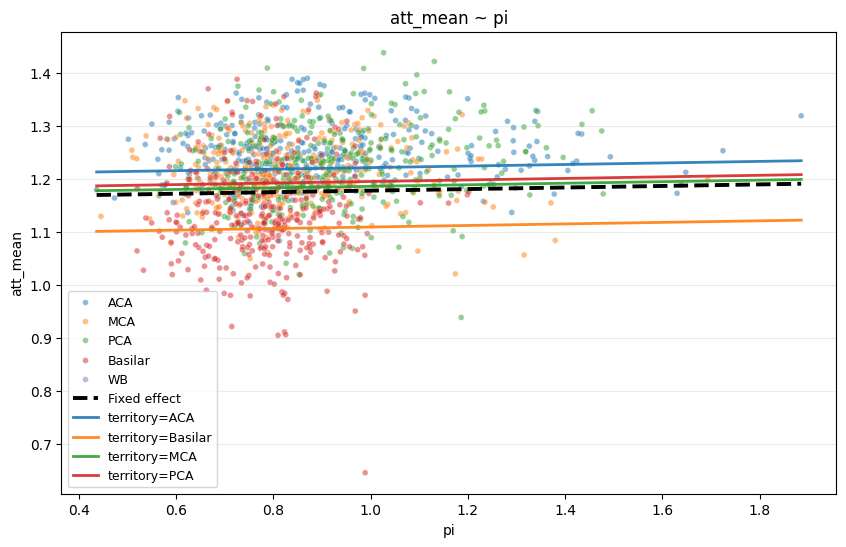

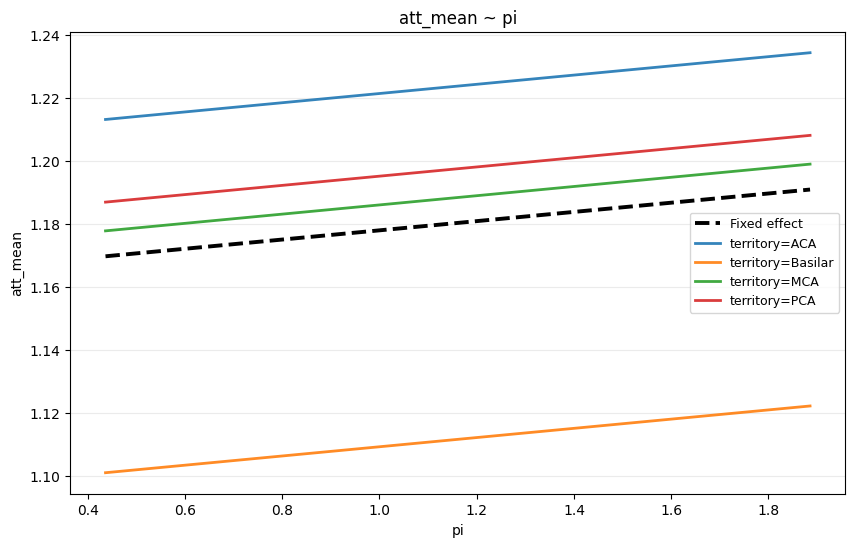

In [7]:
model_dir = 'attm_pi'
formula_m = (
    f"att_mean ~ pi + age_c + sex + hematocrit + score2"
)

_model_cols = [
    "pp",
    "pi",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
    "score2"
]

_res_att_pi, _df_fit_att_pi, _meta_outcome = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
    data=analysis_df,
    formula=formula_m,
    groups="territory",
    re_formula="1",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=False,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    _res_att_pi,
    outcome_name="att_mean",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
)

fig = nv.stats.plot_mixedlm_params(
    result=_res_att_pi,
    df_fit=_df_fit_att_pi,
    x="pi",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=True,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pi",
    x_label="pi",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(_df_fit_att_pi["hematocrit"].mean()), "age_c": float(_df_fit_att_pi["age_c"].mean()), "score2": float(_df_fit_att_pi["score2"].mean())},
)

# fig.axes[0].set_ylim(30, 60)

fig = nv.stats.plot_mixedlm_params(
    result=_res_att_pi,
    df_fit=_df_fit_att_pi,
    x="pi",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pi",
    x_label="pi",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(_df_fit_att_pi["hematocrit"].mean()), "age_c": float(_df_fit_att_pi["age_c"].mean()), "score2": float(_df_fit_att_pi["score2"].mean())},
)

12:31:18 | INFO     | ========================================================================================
Mixed Linear Model - att_mean
Formula: att_mean ~ pp + age_c + sex + hematocrit + score2
Observations: 1,367
territory groups: 4

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                               1.0512      0.0341  1.896e-208       ***
pp                                     -0.0008      0.0002   0.0001401       ***
age_c                                   0.0024      0.0005   4.014e-07       ***
sex                                     0.0453      0.0049   1.817e-20       ***
hematocrit                              0.0035      0.0005   5.621e-12       ***
score2                                  0.0003      0.0014      0.8355        NS

territory random effects covariance
----------------------------------------------------

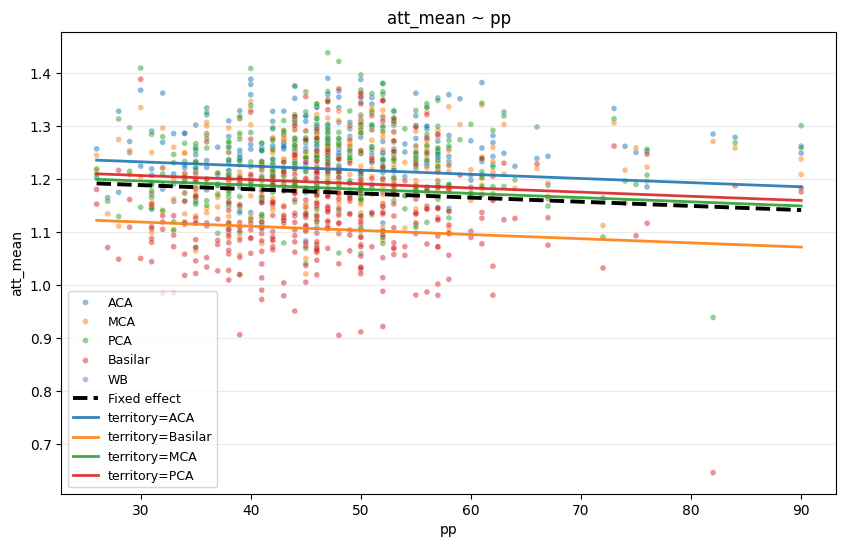

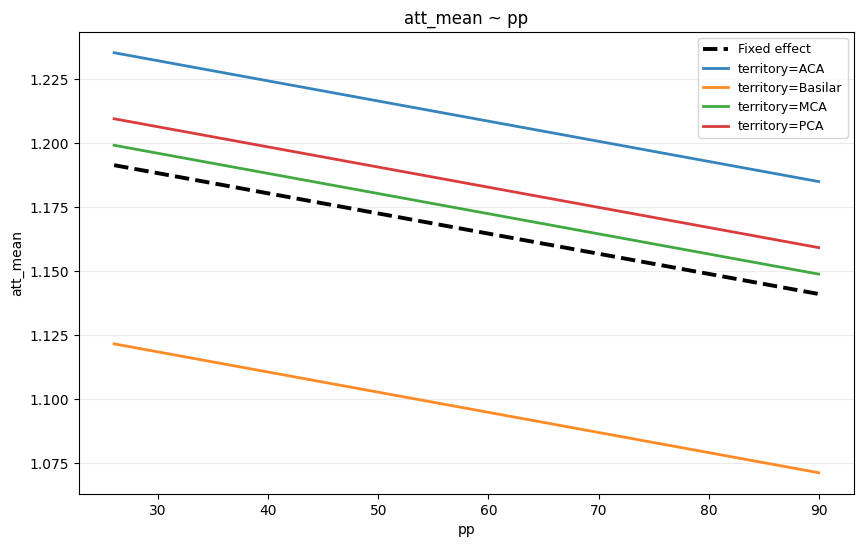

In [8]:
model_dir = 'attm_pp'
formula_m = (
    f"att_mean ~ pp + age_c + sex + hematocrit + score2"
)

_model_cols = [
    "pp",
    "pi",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
    "score2"
]

_res_att_pp, _df_fit_att_pp, _ = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
    data=analysis_df,
    formula=formula_m,
    groups="territory",
    re_formula="1",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=False,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    _res_att_pp,
    outcome_name="att_mean",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
)

fig = nv.stats.plot_mixedlm_params(
    result=_res_att_pp,
    df_fit=_df_fit_att_pp,
    x="pp",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=True,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pp",
    x_label="pp",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(_df_fit_att_pp["hematocrit"].mean()), "age_c": float(_df_fit_att_pp["age_c"].mean()), "score2": float(_df_fit_att_pp["score2"].mean())},
)

# fig.axes[0].set_ylim(30, 60)

fig = nv.stats.plot_mixedlm_params(
    result=_res_att_pp,
    df_fit=_df_fit_att_pp,
    x="pp",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pp",
    x_label="pp",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(_df_fit_att_pp["hematocrit"].mean()), "age_c": float(_df_fit_att_pp["age_c"].mean()), "score2": float(_df_fit_att_pp["score2"].mean())},
)

12:31:19 | INFO     | ========================================================================================
Mixed Linear Model - att_mean
Formula: att_mean ~ pi + pp + age_c + sex + hematocrit + score2
Observations: 1,367
territory groups: 4

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                               1.0332      0.0345   1.73e-196       ***
pi                                      0.0244      0.0105     0.01948         *
pp                                     -0.0009      0.0002   2.271e-05       ***
age_c                                   0.0022      0.0005    5.02e-06       ***
sex                                     0.0465      0.0049   2.494e-21       ***
hematocrit                              0.0036      0.0005   3.487e-12       ***
score2                                  0.0003      0.0014      0.8225        NS

te

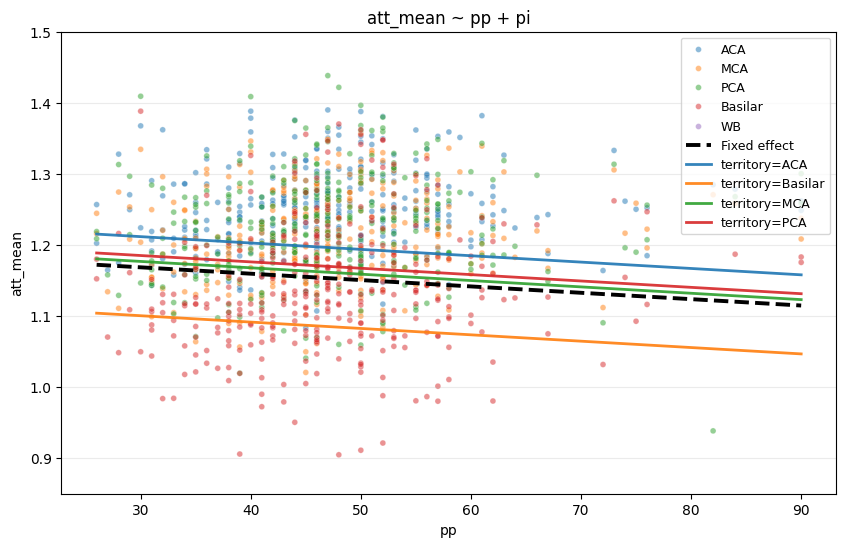

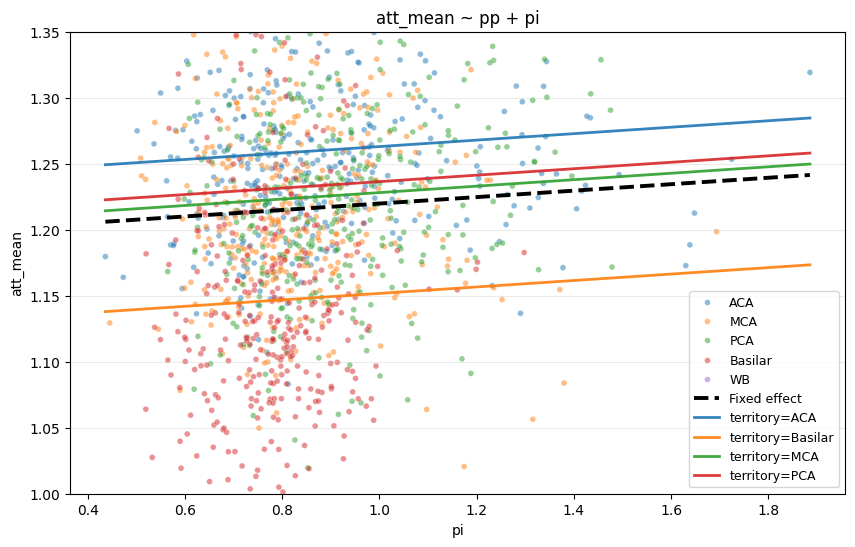

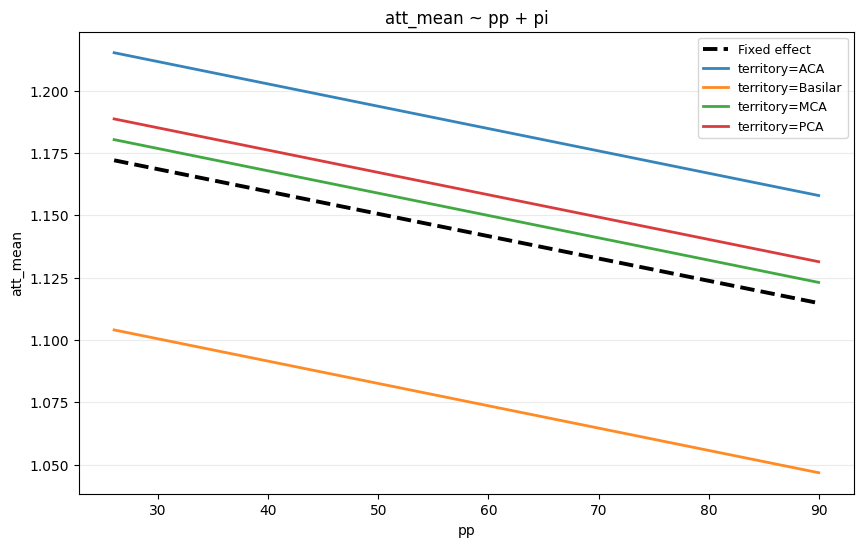

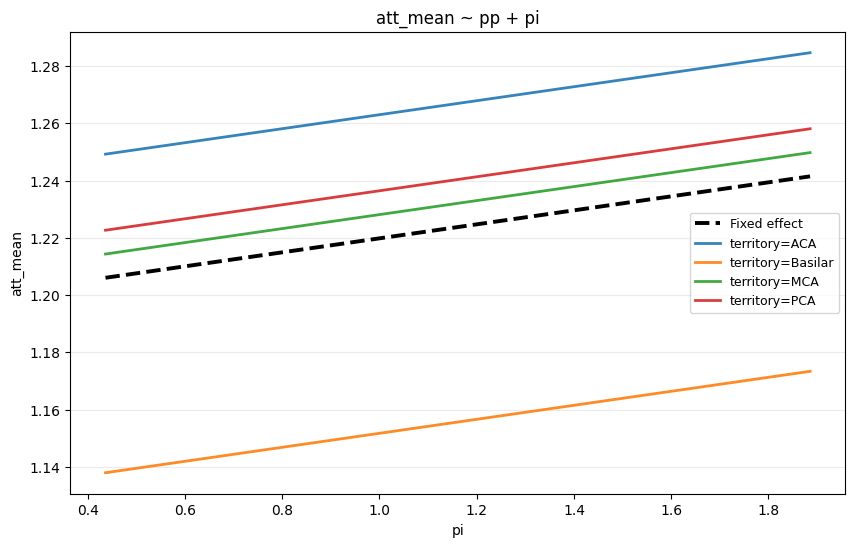

In [9]:
model_dir = 'attm_pp_pi'
formula_m = (
    f"att_mean ~ pi + pp + age_c + sex + hematocrit + score2"
)

_model_cols = [
    "pp",
    "pi",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
    "score2"
]

res_outcome, df_fit_outcome, _meta_outcome = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
    data=analysis_df,
    formula=formula_m,
    groups="territory",
    re_formula="1",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=False,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    res_outcome,
    outcome_name="att_mean",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
)

fig = nv.stats.plot_mixedlm_params(
    result=res_outcome,
    df_fit=df_fit_outcome,
    x="pp",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=True,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pp + pi",
    x_label="pp",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_outcome["hematocrit"].mean()), "age_c": float(df_fit_outcome["age_c"].mean()), "score2": float(df_fit_outcome["score2"].mean())},
)
fig.axes[0].set_ylim(0.85, 1.5)

fig = nv.stats.plot_mixedlm_params(
    result=res_outcome,
    df_fit=df_fit_outcome,
    x="pi",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=True,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pp + pi",
    x_label="pi",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_outcome["hematocrit"].mean()), "age_c": float(df_fit_outcome["age_c"].mean()), "score2": float(df_fit_outcome["score2"].mean())},
)
fig.axes[0].set_ylim(1, 1.35)

fig = nv.stats.plot_mixedlm_params(
    result=res_outcome,
    df_fit=df_fit_outcome,
    x="pp",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pp + pi",
    x_label="pp",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_outcome["hematocrit"].mean()), "age_c": float(df_fit_outcome["age_c"].mean()), "score2": float(df_fit_outcome["score2"].mean())},
)


fig = nv.stats.plot_mixedlm_params(
    result=res_outcome,
    df_fit=df_fit_outcome,
    x="pi",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pp + pi",
    x_label="pi",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_outcome["hematocrit"].mean()), "age_c": float(df_fit_outcome["age_c"].mean()), "score2": float(df_fit_outcome["score2"].mean())},
)

In [10]:
a_effect = res_mediator.params["pp"]
b_effect = res_outcome.params["pi"]
c_prime = res_outcome.params["pp"]

indirect_effect = a_effect * b_effect

print(f"a (pp → pi): {a_effect}")
print(f"b (pi → att): {b_effect}")
print(f"c' (pp → att | pi): {c_prime}")
print(f"Indirect effect (a*b): {indirect_effect}")

a (pp → pi): 0.004471480330506518
b (pi → att): 0.0244414450481636
c' (pp → att | pi): -0.00089545972440546
Indirect effect (a*b): 0.00010928944078201948


Bootstrap

In [78]:
def bootstrap_mediation_mixedlm_by_subject(
    df: pd.DataFrame,
    *,
    formula_m: str,          # mediator model, e.g. "pi ~ pp + age_c + sex + hematocrit + score2"
    formula_y: str,          # outcome model,  e.g. "att_mean ~ pi + pp + age_c + sex + hematocrit + score2"
    x: str = "pp",
    m: str = "pi",
    y: str = "att_mean",
    group_col: str = "territory",
    subject_col: str = "subject_uid",
    required_columns: list[str] | None = None,
    n_boot: int = 2000,
    seed: int = 42,
    fit_kwargs: dict | None = None,
    ci: float = 0.95,
    return_dist: bool = True,
):
    """
    Cluster bootstrap mediation for MixedLM models by resampling subjects (with replacement)
    and keeping all within-subject rows (e.g., territories).
    Fits:
      M: m ~ x + covars + (1|group_col) + (1|subject_col via vc_formula)
      Y: y ~ m + x + covars + (1|group_col) + (1|subject_col via vc_formula)
    Returns percentile CIs + bootstrap p-values for indirect/direct/total.
    """
    fit_kwargs = dict(fit_kwargs or {})
    rng = np.random.default_rng(seed)
    # point estimate from original data (optional but useful)
    res_m0, _, _ = nv.stats.fit_or_load_mixedlm(
        model_path=None,
        data=df,
        formula=formula_m,
        groups=group_col,
        re_formula="1",
        vc_formula={"subject": f"0 + C({subject_col})"},
        overwrite=True,
        required_columns=required_columns,
        fit_kwargs=fit_kwargs,
    )
    res_y0, _, _ = nv.stats.fit_or_load_mixedlm(
        model_path=None,
        data=df,
        formula=formula_y,
        groups=group_col,
        re_formula="1",
        vc_formula={"subject": f"0 + C({subject_col})"},
        overwrite=True,
        required_columns=required_columns,
        fit_kwargs=fit_kwargs,
    )
    a0 = float(res_m0.params[x])
    b0 = float(res_y0.params[m])
    cprime0 = float(res_y0.params[x])
    ind0 = a0 * b0
    tot0 = ind0 + cprime0
    subjects = pd.unique(df[subject_col].dropna())
    indirect = []
    direct = []
    total = []
    a_s = []
    b_s = []
    cprime_s = []
    alpha = 1.0 - ci
    q_lo = 100 * (alpha / 2.0)
    q_hi = 100 * (1.0 - alpha / 2.0)
    for _ in range(n_boot):
        sampled = rng.choice(subjects, size=len(subjects), replace=True)
        # build bootstrap dataset; relabel subject IDs so vc groups stay unique even if repeated
        parts = []
        for i, sid in enumerate(sampled):
            d = df.loc[df[subject_col] == sid].copy()
            d[subject_col] = f"{sid}__boot{i}"
            parts.append(d)
        df_boot = pd.concat(parts, ignore_index=True)
        try:
            res_m, _, _ = nv.stats.fit_or_load_mixedlm(
                model_path=None,
                data=df_boot,
                formula=formula_m,
                groups=group_col,
                re_formula="1",
                vc_formula={"subject": f"0 + C({subject_col})"},
                overwrite=True,
                required_columns=required_columns,
                fit_kwargs=fit_kwargs,
            )
            res_y, _, _ = nv.stats.fit_or_load_mixedlm(
                model_path=None,
                data=df_boot,
                formula=formula_y,
                groups=group_col,
                re_formula="1",
                vc_formula={"subject": f"0 + C({subject_col})"},
                overwrite=True,
                required_columns=required_columns,
                fit_kwargs=fit_kwargs,
            )
            a = float(res_m.params[x])
            b = float(res_y.params[m])
            cprime = float(res_y.params[x])
            a_s.append(a)
            b_s.append(b)
            cprime_s.append(cprime)
            ind = a * b
            indirect.append(ind)
            direct.append(cprime)
            total.append(ind + cprime)
        except Exception:
            # MixedLM can fail to converge on some resamples; skip those draws
            continue
    indirect = np.asarray(indirect, dtype=float)
    direct = np.asarray(direct, dtype=float)
    total = np.asarray(total, dtype=float)
    a_s = np.asarray(a_s, dtype=float)
    b_s = np.asarray(b_s, dtype=float)
    cprime_s = np.asarray(cprime_s, dtype=float)
    def _summ(x):
        ci_lo = float(np.nanpercentile(x, q_lo))
        ci_hi = float(np.nanpercentile(x, q_hi))
        mean = float(np.nanmean(x))
        p = 2 * min(float(np.mean(x <= 0)), float(np.mean(x >= 0)))  # two-sided bootstrap p
        return {"mean": mean, "ci_low": ci_lo, "ci_high": ci_hi, "p_value": p, "n": int(np.sum(np.isfinite(x)))}
    out = {
        "point_estimate": {
            "a": a0,
            "b": b0,
            "c_prime": cprime0,
            "indirect": ind0,
            "direct": cprime0,
            "total": tot0,
        },
        "bootstrap": {
            "a": _summ(a_s),
            "b": _summ(b_s),
            "c_prime": _summ(cprime_s),
            "indirect": _summ(indirect),
            "direct": _summ(direct),
            "total": _summ(total),
        },
    }
    if return_dist:
        out["dist"] = {
            "a": a_s,
            "b": b_s,
            "c_prime": cprime_s,
            "indirect": indirect,
            "direct": direct,
            "total": total,
        }
    return out

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def mediation_boot_to_stats_df(
    boot_res: dict,
    *,
    include_total: bool = True,
    ci_labels=("CI2.5", "CI97.5"),
):
    """
    Convert bootstrap mediation result dict -> a Pingouin-like table:
    columns: path, coef, CI2.5, CI97.5, pval, n_boot

    Expects:
      boot_res["point_estimate"][...]
      boot_res["bootstrap"][...]["ci_low"/"ci_high"/"p_value"/"n"]
    """
    pe = boot_res["point_estimate"]
    bs = boot_res["bootstrap"]

    rows = [
        ("a", pe["a"], bs["a"]),
        ("b", pe["b"], bs["b"]),
        ("c'", pe["c_prime"], bs["c_prime"]),
        ("Indirect", pe["indirect"], bs["indirect"]),
        ("Direct", pe["direct"], bs["direct"]),
    ]
    if include_total and ("total" in pe) and ("total" in bs):
        rows.append(("Total", pe["total"], bs["total"]))

    out = []
    for path, coef, summ in rows:
        out.append(
            {
                "path": path,
                "coef": float(coef),
                "CI2.5": float(summ["ci_low"]),
                "CI97.5": float(summ["ci_high"]),
                "pval": float(summ["p_value"]),
                "n_boot": int(summ["n"]),
            }
        )
    return pd.DataFrame(out)


def plot_mediation_paths_forest_mixedlm(med_stats: pd.DataFrame, ax=None):
    """
    Forest plot for mediation paths, Pingouin-like, using columns:
      path, coef, CI2.5, CI97.5
    """
    df = med_stats.copy()

    preferred_order = ["a", "b", "c'", "Indirect"] # , "Total"
    order = [p for p in preferred_order if p in df["path"].values]
    if not order:
        order = df["path"].tolist()

    df = df[df["path"].isin(order)].copy()
    df["path"] = pd.Categorical(df["path"], categories=order, ordered=True)
    df = df.sort_values("path")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, max(4, 0.6 * len(df))))
    else:
        fig = ax.figure

    y = np.arange(len(df))
    coef = df["coef"].to_numpy(float)
    lo = df["CI2.5"].to_numpy(float)
    hi = df["CI97.5"].to_numpy(float)
    xerr = np.vstack([coef - lo, hi - coef])

    ax.errorbar(
        coef, y, xerr=xerr,
        fmt="o", color="#4C72B0", ecolor="#4C72B0", capsize=4,
    )
    ax.axvline(0, color="black", lw=1.5, ls="--")
    ax.set_yticks(y)
    ax.set_yticklabels(df["path"].astype(str))
    ax.set_xlabel("Effect size (coef with 95% CI)")
    ax.set_title("Mediation Path Estimates (MixedLM bootstrap)")
    ax.grid(True, axis="x", alpha=0.2)
    return fig, ax

def plot_indirect_bootstrap(boot_dist, ci_low=None, ci_high=None, ax=None, bins=50):
    """
    Plot bootstrap distribution of indirect effect (a*b).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    boot_dist = np.asarray(boot_dist)
    ax.hist(boot_dist, bins=bins, alpha=0.35, color="#4C72B0", density=True)

    # KDE overlay
    xs = np.linspace(np.min(boot_dist), np.max(boot_dist), 300)
    kde = gaussian_kde(boot_dist)
    ax.plot(xs, kde(xs), color="#1F4E79", lw=2, label="KDE")

    # Reference lines
    ax.axvline(0, color="black", ls="--", lw=1.5, label="0 (null)")
    if ci_low is None:
        ci_low = np.percentile(boot_dist, 2.5)
    if ci_high is None:
        ci_high = np.percentile(boot_dist, 97.5)

    ax.axvline(ci_low, color="#C44E52", ls="--", lw=2, label=f"CI low: {ci_low:.4f}")
    ax.axvline(ci_high, color="#55A868", ls="--", lw=2, label=f"CI high: {ci_high:.4f}")

    ax.set_title("Bootstrap Distribution of Indirect Effect (a*b)")
    ax.set_xlabel("Indirect effect")
    ax.set_ylabel("Density")
    ax.legend(frameon=True)
    return fig, ax

import seaborn as sns
import statsmodels.api as sm


def _residualize(y, X):
    X = sm.add_constant(X, has_constant="add")
    return sm.OLS(y, X, missing="drop").fit().resid


def plot_partial_paths_mediation(
    df,
    *,
    x="pp",
    m="pi",
    y="att_mean",
    covars=("age_c", "sex", "hematocrit", "score2"),
    figsize=(12, 5),
):
    """
    Visualize adjusted relationships (fixed-effects-style partial plots):
      - a path: residual(m | covars) vs residual(x | covars)
      - b path: residual(y | x+covars) vs residual(m | x+covars)

    Note: This is not a mixed-model partial plot; it’s a useful visualization.
    """
    d = df[[x, m, y, *covars]].dropna().copy()
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # a path: m ~ x + covars  => partial: m|covars vs x|covars
    rx = _residualize(d[x], d[list(covars)])
    rm = _residualize(d[m], d[list(covars)])
    sns.regplot(x=rx, y=rm, ax=axes[0], scatter_kws={"alpha": 0.6}, line_kws={"color": "#C44E52"})
    axes[0].set_title(f"a path (adjusted): {x} → {m}")
    axes[0].set_xlabel(f"{x} residualized on covariates")
    axes[0].set_ylabel(f"{m} residualized on covariates")

    # b path: y ~ m + x + covars => partial: y|(x+covars) vs m|(x+covars)
    rm_x = _residualize(d[m], d[[x, *covars]])
    ry_x = _residualize(d[y], d[[x, *covars]])
    sns.regplot(x=rm_x, y=ry_x, ax=axes[1], scatter_kws={"alpha": 0.6}, line_kws={"color": "#55A868"})
    axes[1].set_title(f"b path (adjusted): {m} → {y} | {x}")
    axes[1].set_xlabel(f"{m} residualized on {x}+covariates")
    axes[1].set_ylabel(f"{y} residualized on {x}+covariates")

    plt.tight_layout()
    return fig, axes

In [69]:
res = bootstrap_mediation_mixedlm_by_subject(
    analysis_df,
    formula_m="pi ~ pp + age_c + sex + hematocrit + score2",
    formula_y="att_mean ~ pi + pp + age_c + sex + hematocrit + score2",
    required_columns=["att_mean", "pi", "pp", "age_c", "sex", "hematocrit", "score2", "territory", "subject_uid"],
    n_boot=50,
    seed=1,
    return_dist=True,
)
res["point_estimate"], res["bootstrap"]["indirect"]

({'a': 0.004471480330506518,
  'b': 0.0244414450481636,
  'c_prime': -0.00089545972440546,
  'indirect': 0.00010928944078201948,
  'direct': -0.00089545972440546,
  'total': -0.0007861702836234406},
 {'mean': 9.010949325826757e-05,
  'ci_low': 1.9658215829728598e-05,
  'ci_high': 0.000193741546481218,
  'p_value': 0.04,
  'n': 50})

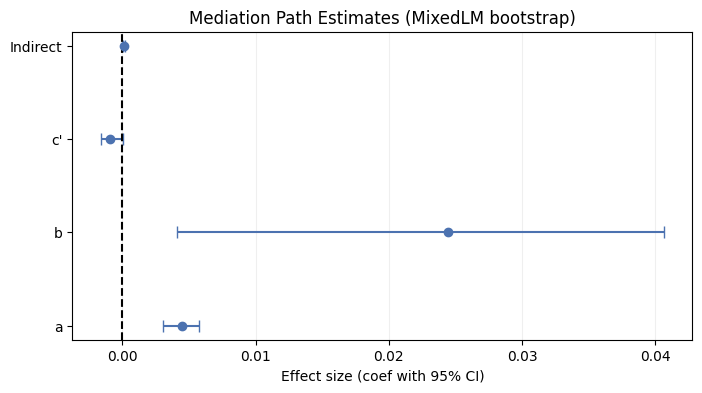

: 

In [ ]:
med_stats = mediation_boot_to_stats_df(res)
fig, ax = plot_mediation_paths_forest_mixedlm(med_stats)

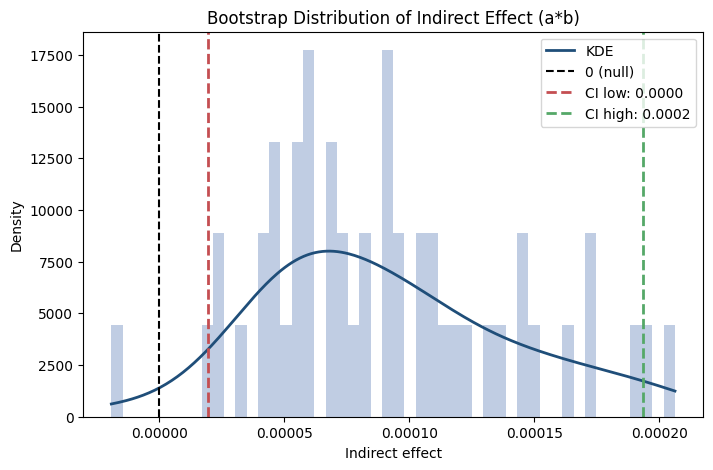

In [71]:
fig, ax = plot_indirect_bootstrap(
    res["dist"]["indirect"],
    ci_low=res["bootstrap"]["indirect"]["ci_low"],
    ci_high=res["bootstrap"]["indirect"]["ci_high"],
)

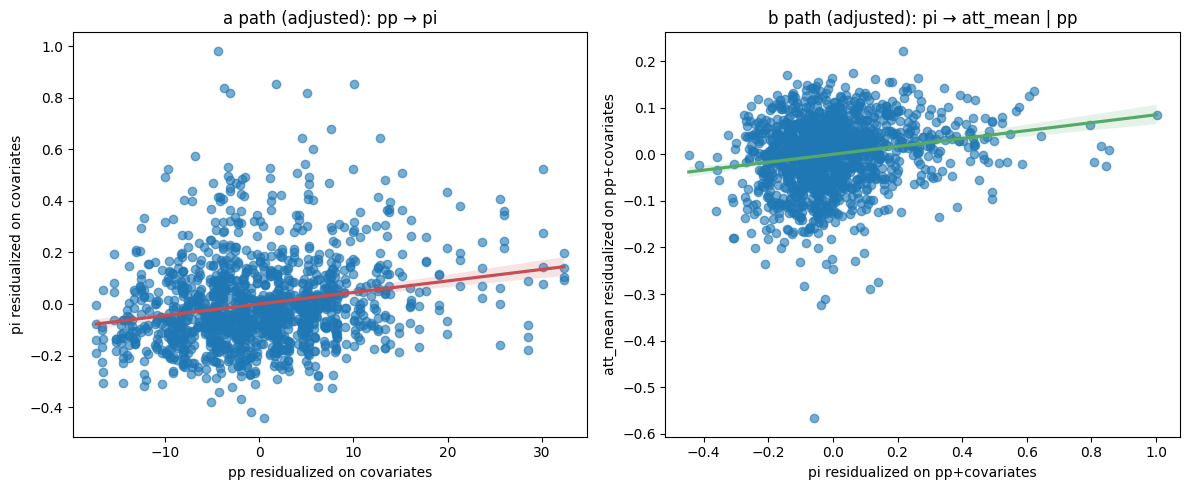

In [ ]:
fig, axes = plot_partial_paths_mediation(analysis_df, x="pp", m="pi", y="att_mean")

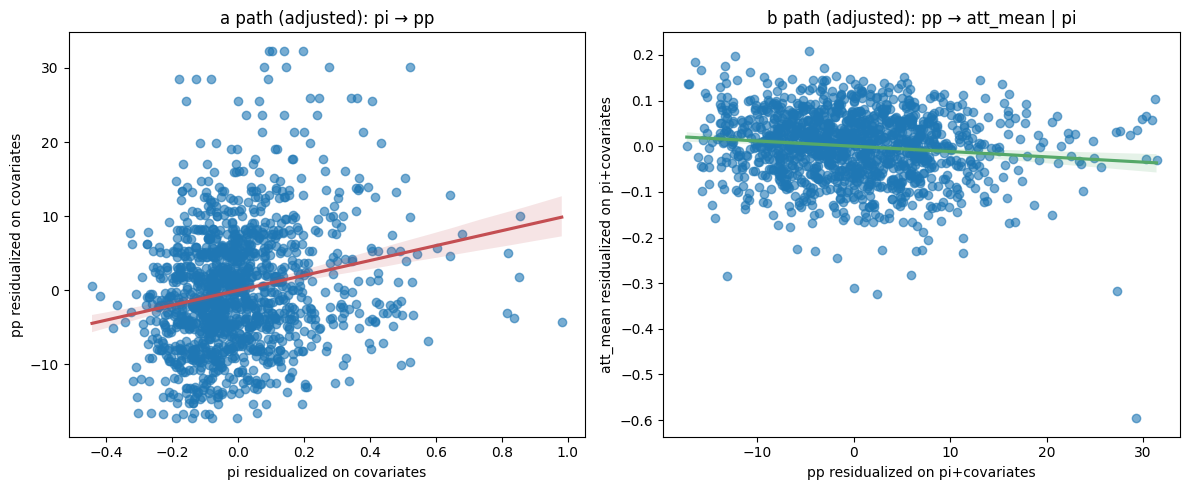

In [73]:
fig, axes = plot_partial_paths_mediation(analysis_df, x="pi", m="pp", y="att_mean")

Mediacion con pengouin

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

def plot_mediation_paths_forest(med_stats, ax=None, terr=None):
    """
    Forest plot for mediation path coefficients and CIs from pingouin result table.
    Expects columns like: path, coef, CI[2.5%], CI[97.5%]
    """
    df = med_stats.copy()

    # Keep common paths if present, otherwise show all
    preferred_order = ["a", "b", "c", "c'", "Indirect", "Direct", "Total"]
    paths_present = [p for p in preferred_order if p in df["path"].values]
    if len(paths_present) == 0:
        paths_present = df["path"].tolist()

    df = df[df["path"].isin(paths_present)].copy()
    df["path"] = pd.Categorical(df["path"], categories=paths_present, ordered=True)
    df = df.sort_values("path")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    y = np.arange(len(df))
    coef = df["coef"].values
    lo = df["CI2.5"].values
    hi = df["CI97.5"].values

    xerr = np.vstack([coef - lo, hi - coef])
    ax.errorbar(coef, y, xerr=xerr, fmt="o", color="#4C72B0", ecolor="#4C72B0", capsize=4)

    ax.axvline(0, color="black", lw=1.5, ls="--")
    ax.set_yticks(y)
    ax.set_yticklabels(df["path"])
    ax.set_xlabel("Effect size (coef with 95% CI)")
    ax.set_title("Mediation Path Estimates " + terr if terr is not None else "")
    return fig, ax

import statsmodels.api as sm

def _residualize(y, X):
    X = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X, missing="drop").fit()
    return model.resid

def plot_partial_paths(df, x="pi", m="pp", y="att_mean",
                       covars=("age_c", "sex", "hematocrit", "score2"),
                       figsize=(12, 5)):
    """
    Visualize adjusted relationships:
      - a path: M ~ X + covars
      - b path: Y ~ M + X + covars  (show Y residualized against X+covars vs M residualized against X+covars)
    """
    d = df[[x, m, y, *covars]].dropna().copy()

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # a path partial plot: residual(M|covars) vs residual(X|covars)
    rx = _residualize(d[x], d[list(covars)])
    rm = _residualize(d[m], d[list(covars)])
    sns.regplot(x=rx, y=rm, ax=axes[0], scatter_kws={"alpha": 0.6}, line_kws={"color": "#C44E52"})
    axes[0].set_title("a path (adjusted): pi -> pp")
    axes[0].set_xlabel(f"{x} residualized on covariates")
    axes[0].set_ylabel(f"{m} residualized on covariates")

    # b path partial plot: residual(Y|X+covars) vs residual(M|X+covars)
    rmx = _residualize(d[m], d[[x, *covars]])
    ryx = _residualize(d[y], d[[x, *covars]])
    sns.regplot(x=rmx, y=ryx, ax=axes[1], scatter_kws={"alpha": 0.6}, line_kws={"color": "#55A868"})
    axes[1].set_title("b path (adjusted): pp -> att_mean | pi")
    axes[1].set_xlabel(f"{m} residualized on {x}+covariates")
    axes[1].set_ylabel(f"{y} residualized on {x}+covariates")

    plt.tight_layout()
    return fig, axes

def plot_indirect_by_territory(results_by_territory, ax=None):
    """
    results_by_territory: dict[territory] -> pingouin mediation result DataFrame
    """
    rows = []
    for terr, res in results_by_territory.items():
        r = res[res["path"] == "Indirect"].iloc[0]
        rows.append({
            "territory": terr,
            "coef": r["coef"],
            "lo": r["CI[2.5%]"],
            "hi": r["CI[97.5%]"],
            "pval": r.get("pval", np.nan),
        })
    out = pd.DataFrame(rows).sort_values("coef")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(out))))
    else:
        fig = ax.figure

    y = np.arange(len(out))
    ax.errorbar(out["coef"], y,
                xerr=[out["coef"] - out["lo"], out["hi"] - out["coef"]],
                fmt="o", capsize=4, color="#4C72B0")
    ax.axvline(0, color="black", ls="--", lw=1.2)
    ax.set_yticks(y)
    ax.set_yticklabels(out["territory"])
    ax.set_xlabel("Indirect effect (a*b) with 95% CI")
    ax.set_title("Indirect Effects by Territory")
    return fig, ax, out

       path      coef        se          pval     CI2.5    CI97.5  sig
0    pi ~ X  0.004497  0.000715  9.771241e-10  0.003091  0.005903  Yes
1    Y ~ pi  0.018857  0.026037  4.694131e-01 -0.032358  0.070073   No
2     Total -0.000785  0.000358  2.925437e-02 -0.001490 -0.000080  Yes
3    Direct -0.000972  0.000378  1.060057e-02 -0.001716 -0.000228  Yes
4  Indirect  0.000187  0.000121  1.132000e-01 -0.000033  0.000443   No

Indirect effect row:
       path      coef        se    pval     CI2.5    CI97.5 sig
4  Indirect  0.000187  0.000121  0.1132 -0.000033  0.000443  No


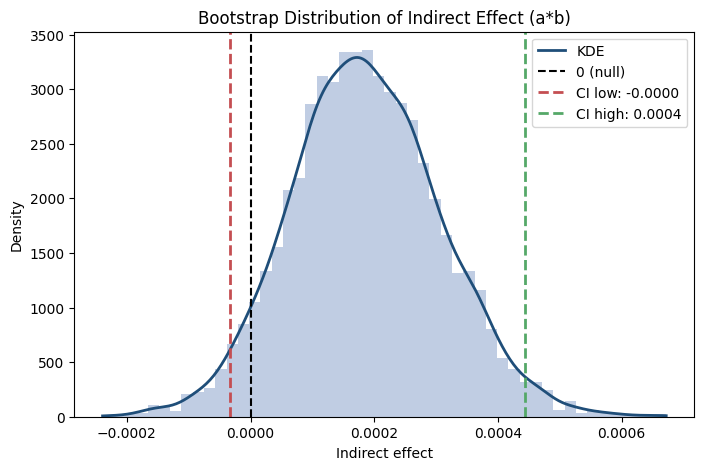

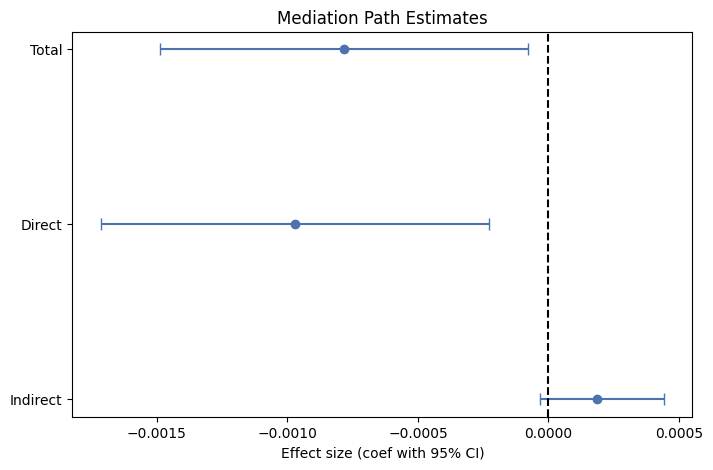

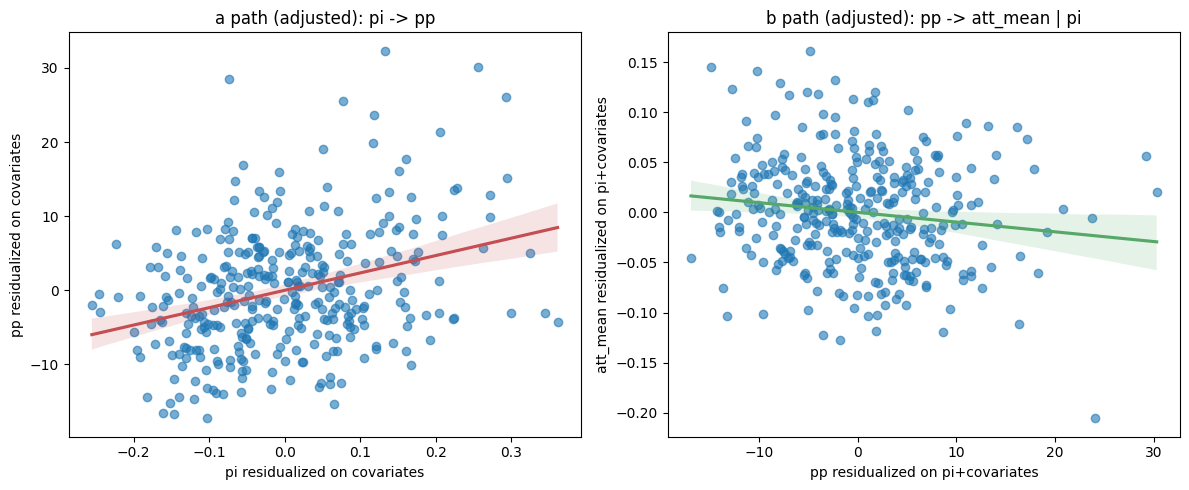

In [25]:
import pingouin as pg


# Match the same columns used in the notebook
model_cols = [
    "subject_uid", "territory",
    "pi", "pp", "att_mean",
    "age_c", "sex", "hematocrit", "score2"
]

df = analysis_df[model_cols].dropna().copy()

# IMPORTANT:
# pingouin mediation_analysis is not mixed-effects.
# To avoid pseudo-replication across territories, aggregate to subject-level first.
df_subj = (
    df.groupby("subject_uid", as_index=False)
      .agg({
          "pi": "mean",
          "pp": "mean",
          "att_mean": "mean",
          "age_c": "mean",
          "sex": "first",
          "hematocrit": "mean",
          "score2": "mean",
      })
)

# Mediation: X=pi, M=pp, Y=att_mean, with same covariates as your model
med = pg.mediation_analysis(
    data=df_subj,
    x="pp",
    m="pi",
    y="att_mean",
    covar=["age_c", "sex", "hematocrit", "score2"],
    n_boot=5000,
    alpha=0.05,
    seed=1234,
    return_dist=True,  # returns bootstrap distribution of indirect effect
)

# pingouin returns (stats_df, boot_dist) when return_dist=True
med_stats, boot_dist = med

print(med_stats)
print("\nIndirect effect row:")
print(med_stats.loc[med_stats["path"] == "Indirect"])

# 1) Distribution of indirect effect
ind_row = med_stats.loc[med_stats["path"] == "Indirect"].iloc[0]
plot_indirect_bootstrap(boot_dist, ci_low=ind_row["CI2.5"], ci_high=ind_row["CI97.5"])

# 2) Forest plot of all paths
plot_mediation_paths_forest(med_stats)

# 3) Adjusted path visualizations
plot_partial_paths(df_subj, x="pi", m="pp", y="att_mean",
                   covars=("age_c", "sex", "hematocrit", "score2"))
plt.show()

Pengouin by territory

In [54]:
import numpy as np
import pandas as pd
import pingouin as pg

def pingouin_mediation_by_territory(
    df: pd.DataFrame,
    *,
    territory_col="territory",
    x="pp",
    m="pi",
    y="att_mean",
    covar=("age_c", "sex", "hematocrit", "score2"),
    n_boot=5000,
    seed=42,
    alpha=0.05,
    dropna=True,
):
    """
    Returns:
      results_by_territory: dict[str, pd.DataFrame]  # pingouin mediation table per territory
      summary_df: pd.DataFrame                       # compact indirect/direct/total per territory
    """
    results_by_territory = {}
    rows = []

    needed = [territory_col, x, m, y, *covar]
    d0 = df[needed].copy()
    if dropna:
        d0 = d0.dropna()

    # pingouin uses numpy global RNG for bootstraps in some paths; set it for reproducibility
    np.random.seed(seed)

    for terr, dterr in d0.groupby(territory_col):
        # Require enough samples to fit the models; tune threshold if needed
        if len(dterr) < max(20, 5 + len(covar) * 3):
            continue

        res = pg.mediation_analysis(
            data=dterr,
            x=x,
            m=m,
            y=y,
            covar=list(covar),
            n_boot=int(n_boot),
            alpha=float(alpha),
            seed=int(seed),
            return_dist=True,   # gives you bootstrap distribution of indirect
        )

        results_by_territory[terr] = res

        # Pull key rows for easy across-territory plotting
        def _row(path):
            r = res[0].loc[res[0]["path"] == path]
            return {
                "coef": float(r["coef"].values[0]),
                "lo": float(r["CI2.5"].values[0]),
                "hi": float(r["CI97.5"].values[0]),
                "pval": float(r["pval"].values[0]),
            }

        ind = _row("Indirect")
        direct = _row("Direct")
        total = _row("Total")

        rows.append({
            "territory": terr,
            "n": int(len(dterr)),
            "indirect": ind["coef"], "ind_lo": ind["lo"], "ind_hi": ind["hi"], "ind_p": ind["pval"],
            "direct": direct["coef"], "dir_lo": direct["lo"], "dir_hi": direct["hi"], "dir_p": direct["pval"],
            "total": total["coef"], "tot_lo": total["lo"], "tot_hi": total["hi"], "tot_p": total["pval"],
            # If present, pingouin includes the bootstrap distribution in the Indirect row
            "boot_dist": res[0].loc[res[0]["path"] == "Indirect"].iloc[0].get("dist", None),
        })

    summary_df = pd.DataFrame(rows).sort_values("indirect")
    return results_by_territory, summary_df

def plot_indirect_by_territory_pingouin(med_summary: pd.DataFrame, ax=None):
    out = med_summary.sort_values("indirect").copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, max(4, 0.5 * len(out))))
    else:
        fig = ax.figure

    y = np.arange(len(out))
    coef = out["indirect"].to_numpy(float)
    lo = out["ind_lo"].to_numpy(float)
    hi = out["ind_hi"].to_numpy(float)

    ax.errorbar(
        coef, y,
        xerr=[coef - lo, hi - coef],
        fmt="o", capsize=4, color="#4C72B0", ecolor="#4C72B0"
    )
    ax.axvline(0, color="black", ls="--", lw=1.2)
    ax.set_yticks(y)
    ax.set_yticklabels(out["territory"].astype(str))
    ax.set_xlabel("Indirect effect (a*b) with 95% CI")
    ax.set_title("Pingouin mediation per territory: Indirect effects")
    ax.grid(True, axis="x", alpha=0.2)

    return fig, ax, out

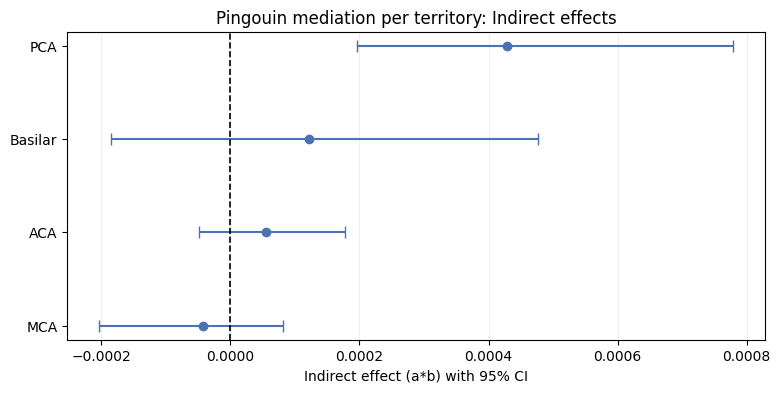

In [55]:
results_by_territory, med_summary = pingouin_mediation_by_territory(
    analysis_df,
    territory_col="territory",
    x="pp",
    m="pi",
    y="att_mean",
    covar=("age_c", "sex", "hematocrit", "score2"),
    n_boot=5000,
    seed=1,
)
med_summary.head()

fig, ax, out = plot_indirect_by_territory_pingouin(med_summary)

In [74]:
med_summary

,territory,n,indirect,ind_lo,ind_hi,ind_p,direct,dir_lo,dir_hi,dir_p,total,tot_lo,tot_hi,tot_p,boot_dist
1,MCA,342,-0.000042,-0.000204,0.000081,0.5632,-0.000437,-0.001108,0.000233,0.200410,-0.000479,-0.001138,0.000179,0.152859,None
0,ACA,342,0.000055,-0.000048,0.000177,0.2968,-0.000681,-0.001290,-0.000073,0.028355,-0.000626,-0.001224,-0.000028,0.040098,None
3,Basilar,341,0.000123,-0.000185,0.000476,0.4428,-0.001349,-0.002460,-0.000238,0.017439,-0.001226,-0.002283,-0.000170,0.022986,None
2,PCA,342,0.000429,0.000196,0.000779,0.0004,-0.001246,-0.002128,-0.000365,0.005721,-0.000817,-0.001681,0.000047,0.063836,None


--- Territory: MCA ---
--- Territory: ACA ---
--- Territory: Basilar ---
--- Territory: PCA ---


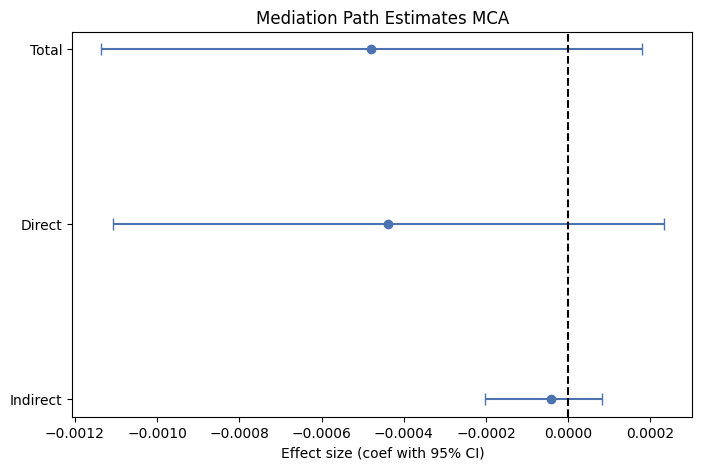

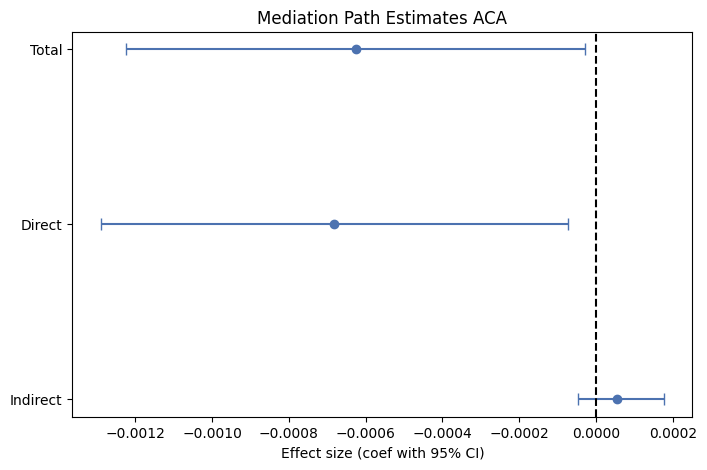

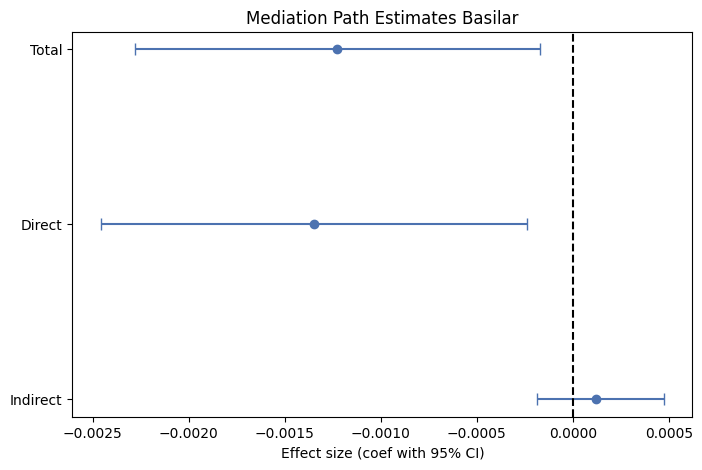

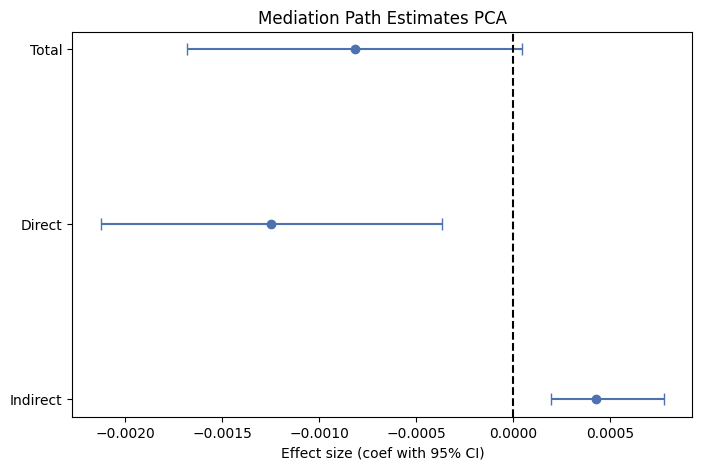

In [ ]:
# Perform this analysis/plot by territory for all unique territories
for terr in out["territory"]:
    print(f"--- Territory: {terr} ---")
    res_t = results_by_territory[terr][0]
    med_stats_t = res_t.rename(columns={"CI[2.5%]": "CI2.5", "CI[97.5%]": "CI97.5"})
    
    fig1, ax1 = plot_mediation_paths_forest(med_stats_t, terr=terr)
    
    # Indirect bootstrap distribution
    ind_row = res_t.loc[res_t["path"] == "Indirect"].iloc[0]
    boot_dist = ind_row.get("dist", None)
    if boot_dist is not None:
        print(f"Boot dist: {boot_dist}")
        fig2, ax2 = plot_indirect_bootstrap(
            boot_dist,
            ci_low=float(ind_row["CI2.5"]),
            ci_high=float(ind_row["CI97.5"]),
        )
    # else:
    #     print("No boot_dist")